## Prerequisites

### Install and import dependencies

In [1]:
%pip install pandas numpy fastplot tldextract plotly[kaleido]

  Using cached fastplot-1.5.0-py3-none-any.whl
  Using cached tldextract-5.3.1-py3-none-any.whl.metadata (7.3 kB)
  Using cached plotly-6.5.1-py3-none-any.whl.metadata (8.5 kB)
  Using cached requests_file-3.0.1-py2.py3-none-any.whl.metadata (1.7 kB)
  Using cached filelock-3.20.3-py3-none-any.whl.metadata (2.1 kB)
  Using cached kaleido-1.2.0-py3-none-any.whl.metadata (5.6 kB)
  Using cached choreographer-1.2.1-py3-none-any.whl.metadata (6.8 kB)
  Using cached logistro-2.0.1-py3-none-any.whl.metadata (3.9 kB)
  Using cached orjson-3.11.5-cp313-cp313-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (41 kB)
  Using cached pytest_timeout-2.4.0-py3-none-any.whl.metadata (20 kB)
  Using cached simplejson-3.20.2-cp313-cp313-manylinux_2_5_x86_64.manylinux1_x86_64.manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (3.4 kB)
  Using cached pytest-9.0.2-py3-none-any.whl.metadata (7.6 kB)
  Using cached iniconfig-2.3.0-py3-none-any.whl.metadata (2.5 kB)
Using cached tldextract-5.3.1-p

In [2]:
from plotly.io import get_chrome
get_chrome()

PosixPath('/opt/conda/lib/python3.13/site-packages/choreographer/cli/browser_exe/chrome-linux64/chrome')

In [3]:
import json
from collections import defaultdict

import pandas as pd
import numpy as np
import seaborn as sns
from zipfile import ZipFile

import matplotlib.pyplot as plt
import fastplot as fpl
%matplotlib inline

from cycler import cycler
from collections import Counter

import plotly.graph_objects as go

from pathlib import Path

### Define constants

In [ ]:
INPUT_DATA_DIR = Path("outputs-longitudinal")
ADDITIONAL_DATA_DIR = Path(".")
PLOTS_DIR = Path("plots-longitudinal")

PLOT_ARGS = {"style":"latex", "grid":True, "figsize":(4.25,2.5), "rcParams":{'text.latex.preamble': '\\usepackage{libertine}\\usepackage{setspace}\n\\usepackage{courier}'}, "legend_args":{"columnspacing":1, "handlelength":1.5}}
PLOT_ARGS_LARGE = {"style":"latex", "grid":True, "figsize":(9,3.5), "rcParams":{'text.latex.preamble': '\\usepackage{libertine}\\usepackage{setspace}\n\\usepackage{courier}'}, "legend_args":{"columnspacing":1, "handlelength":1.5}}

VISITS = [ 'first', 'second' ]
VISITS_MAP = {
    ("first", "accept"): '\\textit{Before-Accept}',
    ("first", "deny"): '\\textit{Before-Deny}',
    ("first", "any"): '\\textit{Before-Click}',
    ("second", "accept"): '\\textit{After-Accept}',
    ("second", "deny"): '\\textit{After-Deny}'
}

FIELDS = [ 'contacted_domains', 'api_calls', 'cookies' ]
ACTIONS = [ 'accept', 'deny' ]

PRIVACY_SANDBOX_APIS_MAP = {
    'attribution_reporting': 'Attribution Reporting',
    'topics': 'Topics',
    'protected_audience': 'Protected Audience',
    'private_aggregation': 'Private Aggregation',
    'shared_storage': 'Shared Storage',
    'related_website_sets': 'Related Website Sets',
    "chips": 'CHIPS',
    'fenced_frames': 'Fenced Frames',
    'fedcm': 'FedCM',
    'private_state_tokens': 'Private State Tokens',
}
PRIVACY_SANDBOX_APIS = list(PRIVACY_SANDBOX_APIS_MAP.keys())

DEPRECATION_DATE = "20251017"
DEPRECATED_APIS = [ 'attribution_reporting', 'topics', 'protected_audience', 'related_website_sets', 'shared_storage' ]
SUPPORTED_APIS = [ 'private_state_tokens', 'chips', 'fenced_frames', 'fedcm' ]

API_CALL_INTERCEPTION_TYPES = [ 'javascript_functions', 'cdp_events', "db_data" ]

CALLER_TYPE = "script"

### Define common functions

* Domain extraction:

In [5]:
import tldextract
extract = tldextract.TLDExtract(include_psl_private_domains=True)

def getGood2LD(url) -> str:
    if url == "UNKNOWN_SOURCE":
        return url
    return extract(url).top_domain_under_public_suffix

def getFullDomain(url) -> str:
    if url == "UNKNOWN_SOURCE":
        return url
    return extract(url).fqdn

In [6]:
import tldextract
extract = tldextract.TLDExtract(include_psl_private_domains=True)

with open(ADDITIONAL_DATA_DIR / "domain_map.json", "r") as file:
    de_map = json.load(file)

def is_third_party_domain(domain, other_domain):
    """A function defining whether a domains is third party with respect to another domain.
    Input
    -----
    domain (str): target domain
    other_domain (str): other domain
    Output
    ------
    bool: whether `other_domain` is third party with respect to `domain`
    """
    domain_etld1 = extract(domain).top_domain_under_public_suffix
    domain_en = de_map.get(domain_etld1, {'entityName': False})['entityName']
    other_domain_etld1 = extract(other_domain).top_domain_under_public_suffix
    other_domain_en = de_map.get(other_domain_etld1, {'entityName': False})['entityName']
    if domain_en==False or other_domain_en==False:
        if domain_etld1 != other_domain_etld1:
            return True
    elif domain_en != other_domain_en:
        return True
    return False

* Plot styling:

In [7]:
DEFAULT_HATCHES = [ "\\\\\\\\\\", "/////" ]
def set_bar_colors(plot, colors, legend=False, hatches=DEFAULT_HATCHES):
    if isinstance(colors, str):
        colors = [colors]
    x_len = len(plot.gca().get_xticklabels())
    for i,c in enumerate(colors):
        try:
            for p in plot.gca().patches[i*x_len:(i+1)*x_len] + ([plot.gca().get_legend().get_patches()[i]] if legend else []):
                p.set_hatch(hatches[i % len(hatches)])
                if isinstance(c, tuple):
                    p.set_edgecolor(c[0])
                    p.set_facecolor(c[1])
                elif isinstance(c, str):
                    p.set_edgecolor(c)
                    p.set_facecolor('white')
                else:
                    raise ValueError(f"Invalid color format: {c}. Expected tuple or string.")
        except IndexError:
            pass

def add_numbers_top(plot, numbers, title=None, y_level=None):
    if y_level is None:
        y_level = plot.gca().get_ylim()[1] * 1.05
    if title is not None:
        plot.gca().text(len(numbers)/2, y_level+(plot.gca().get_ylim()[1]*0.10), title, ha='center', fontsize=10)
    for i, v in enumerate(numbers):
        try:
            plot.gca().text(i, y_level, str(v), color='black', ha='center', fontsize=8)
        except IndexError:
            pass

def save_plot(plot, name, opts = { 'dpi':300 }):
    for ext in [ "pdf", "svg", "png" ]:
        plot.savefig(f"{PLOTS_DIR}/{ext}/{name}.{ext}", **opts)

def save_sankey(fig, name, opts = { }):
    for ext in [ "pdf", "svg", "png" ]:
        fig.write_image(f"{PLOTS_DIR}/{ext}/{name}.{ext}", **opts)

### Create output folders

In [42]:
for subfolder in [ "pdf", "svg", "png", "pickle" ]:
    (PLOTS_DIR / subfolder).mkdir(parents=True, exist_ok=True)

## Data import

In [9]:
base_dir = Path(INPUT_DATA_DIR).expanduser()

crawling_frames = []

for zip_file in sorted(base_dir.iterdir()):
    if zip_file.suffix != ".zip":
        continue
    
    print(f'Reading {zip_file.name}')

    date = zip_file.name.split("-")[-1][:-4]
    with ZipFile(zip_file, 'r') as archive:
        df_crawling = pd.read_csv(archive.open('crawler_outputs.csv'))
        df_crawling["date"] = date

    crawling_frames.append(df_crawling)

df_crawling = pd.concat(crawling_frames)
df_crawling.head()

Reading outputs-20250623.zip
Reading outputs-20250630.zip
Reading outputs-20250707.zip
Reading outputs-20250714.zip
Reading outputs-20250721.zip
Reading outputs-20250728.zip
Reading outputs-20250804.zip
Reading outputs-20250811.zip
Reading outputs-20250818.zip
Reading outputs-20250825.zip
Reading outputs-20250901.zip
Reading outputs-20250908.zip
Reading outputs-20250915.zip
Reading outputs-20250922.zip
Reading outputs-20250929.zip
Reading outputs-20251006.zip
Reading outputs-20251013.zip
Reading outputs-20251020.zip
Reading outputs-20251027.zip
Reading outputs-20251103.zip
Reading outputs-20251110.zip
Reading outputs-20251117.zip
Reading outputs-20251124.zip
Reading outputs-20251201.zip
Reading outputs-20251208.zip
Reading outputs-20251215.zip
Reading outputs-20251222.zip
Reading outputs-20251229.zip
Reading outputs-20260105.zip


,position,website,first_contacted_domains_accept,first_api_calls_accept,first_cookies_accept,second_contacted_domains_accept,second_api_calls_accept,second_cookies_accept,first_contacted_domains_deny,first_api_calls_deny,first_cookies_deny,second_contacted_domains_deny,second_api_calls_deny,second_cookies_deny,date
0,1,http://google.com/,"[""fonts.gstatic.com"",""google.com"",""ogads-pa.cl...","{""topics"":{""javascript_functions"":[],""cdp_even...","[{""domain"":"".google.com"",""expires"":1766266484....","[""fonts.gstatic.com"",""google.com"",""ogads-pa.cl...","{""topics"":{""javascript_functions"":[],""cdp_even...","[{""domain"":"".google.com"",""expires"":1766525706....","[""fonts.gstatic.com"",""google.com"",""ogads-pa.cl...","{""topics"":{""javascript_functions"":[],""cdp_even...","[{""domain"":"".google.com"",""expires"":1766266483....","[""fonts.gstatic.com"",""google.com"",""ogads-pa.cl...","{""topics"":{""javascript_functions"":[],""cdp_even...","[{""domain"":"".google.com"",""expires"":1766266483....",20250623
1,2,http://mail.ru/,"[""531311.ms.dzen.ru"",""a.delivery.consentmanage...","{""topics"":{""javascript_functions"":[{""descripti...","[{""domain"":"".mail.ru"",""expires"":-1,""httpOnly"":...","[""531311.ms.dzen.ru"",""a.delivery.consentmanage...","{""topics"":{""javascript_functions"":[{""descripti...","[{""domain"":"".mail.ru"",""expires"":-1,""httpOnly"":...","[""531311.ms.dzen.ru"",""a.delivery.consentmanage...","{""topics"":{""javascript_functions"":[{""descripti...","[{""domain"":"".mail.ru"",""expires"":-1,""httpOnly"":...","[""531311.ms.dzen.ru"",""a.delivery.consentmanage...","{""topics"":{""javascript_functions"":[{""descripti...","[{""domain"":"".mail.ru"",""expires"":-1,""httpOnly"":...",20250623
2,3,http://microsoft.com/,"[""assets.adobedtm.com"",""browser.events.data.mi...","{""topics"":{""javascript_functions"":[],""cdp_even...","[{""domain"":""www.microsoft.com"",""expires"":17507...","[""ad.doubleclick.net"",""adservice.google.com"",""...","{""topics"":{""javascript_functions"":[],""cdp_even...","[{""domain"":""www.microsoft.com"",""expires"":17507...","[""assets.adobedtm.com"",""browser.events.data.mi...","{""topics"":{""javascript_functions"":[],""cdp_even...","[{""domain"":""www.microsoft.com"",""expires"":17507...","[""assets.adobedtm.com"",""browser.events.data.mi...","{""topics"":{""javascript_functions"":[],""cdp_even...","[{""domain"":""www.microsoft.com"",""expires"":17507...",20250623
3,4,http://facebook.com/,"[""facebook.com"",""static.xx.fbcdn.net"",""www.fac...","{""topics"":{""javascript_functions"":[],""cdp_even...",[],"[""facebook.com"",""static.xx.fbcdn.net"",""www.fac...","{""topics"":{""javascript_functions"":[],""cdp_even...","[{""domain"":"".facebook.com"",""expires"":178527453...","[""facebook.com"",""static.xx.fbcdn.net"",""www.fac...","{""topics"":{""javascript_functions"":[],""cdp_even...",[],"[""facebook.com"",""static.xx.fbcdn.net"",""www.fac...","{""topics"":{""javascript_functions"":[],""cdp_even...","[{""domain"":"".facebook.com"",""expires"":178527453...",20250623
4,5,http://apple.com/,"[""apple.com"",""is1-ssl.mzstatic.com"",""securemet...","{""topics"":{""javascript_functions"":[],""cdp_even...","[{""domain"":"".apple.com"",""expires"":-1,""httpOnly...","[""apple.com"",""is1-ssl.mzstatic.com"",""securemet...","{""topics"":{""javascript_functions"":[],""cdp_even...","[{""domain"":"".apple.com"",""expires"":-1,""httpOnly...","[""apple.com"",""is1-ssl.mzstatic.com"",""securemet...","{""topics"":{""javascript_functions"":[],""cdp_even...","[{""domain"":"".apple.com"",""expires"":-1,""httpOnly...",NaN,NaN,NaN,20250623


# Pre-processing

* Parse JSON objects:

In [10]:
for visit in VISITS:
    for field in FIELDS:
        for action in ACTIONS:
            mk_not_null = ~df_crawling[f"{visit}_{field}_{action}"].isna()
            df_crawling.loc[mk_not_null, f"{visit}_{field}_{action}"] = df_crawling.loc[mk_not_null, f"{visit}_{field}_{action}"].apply(json.loads)

* For most measurements, the "cookies" field should be an array. For some, it is that array inside an object with a single "cookies" property. Ensure that all values of this field are arrays

In [11]:
for visit in VISITS:
    for action in ACTIONS:
        mk_cookies_object = df_crawling[f"{visit}_cookies_{action}"].apply(lambda x: isinstance(x, dict))
        df_crawling.loc[mk_cookies_object, f"{visit}_cookies_{action}"] = df_crawling.loc[mk_cookies_object, f"{visit}_cookies_{action}"].apply(lambda x: x["cookies"])

* Parse dates:

In [12]:
df_crawling["date"] = pd.to_datetime(df_crawling["date"], format="%Y%m%d")

* Remove websites where the crawler failed to visit. There are two main cases:
    * The website is `null`
    * The crawler did not contact any domain during the visit, presuming that a connection error occurred. In that case, only drop the visit

In [13]:
rows_no_website = df_crawling["website"].isna().sum()
df_crawling = df_crawling.dropna(subset=["website"])
print(f"Removed {rows_no_website} row(s) without a website.")

visits_no_contacts = 0
for action in ACTIONS:
    for visit in VISITS:
        mk_no_contacts = df_crawling[f"{visit}_contacted_domains_{action}"].apply(lambda domains: isinstance(domains, list) and len(domains) == 0)
        visits_no_contacts += mk_no_contacts.sum()
        df_crawling.loc[mk_no_contacts, [f"{visit}_{field}_{action}" for field in FIELDS]] = np.nan
print(f"Cleared {visits_no_contacts} visits without contacted domains")

Removed 1 row(s) without a website.
Cleared 37126 visits without contacted domains


* If the website starts with `data:`, the browser encountered an HTTP error during the first visit. In that case, replace the first visit with the second one.
    * If no second visit is detected, drop the row (likely connection error)

In [14]:
mk_data_url = df_crawling["website"].str.startswith("data:")
rows_data_url = mk_data_url.sum()
print(f"Found {rows_data_url} websites starting with 'data:'")

# Check if there's a valid second visit to replace the first
mk_has_second_accept = ~df_crawling["second_contacted_domains_accept"].isna()
mk_has_second_deny = ~df_crawling["second_contacted_domains_deny"].isna()
mk_has_second_visit = mk_has_second_accept | mk_has_second_deny

# For websites starting with 'data:', replace first visit with second if available
for action in ACTIONS:
    for field in FIELDS:
        mk_replace = mk_data_url & (mk_has_second_accept if action == "accept" else mk_has_second_deny)
        df_crawling.loc[mk_replace, f"first_{field}_{action}"] = df_crawling.loc[mk_replace, f"second_{field}_{action}"]

# Drop rows where website starts with 'data:' and no second visit is available
mk_drop = mk_data_url & (~mk_has_second_visit)
df_crawling = df_crawling[~mk_drop]
print(f"Dropped {mk_drop.sum()} rows with 'data:' websites and no second visit")
print(f"Replaced first visits for {(mk_data_url & mk_has_second_visit).sum()} websites with 'data:' URLs")

# Add unique placeholder website for non-dropped URLs starting with 'data:'
# TODO: get real website if possible
mk_data_url = df_crawling["website"].str.startswith("data:")

unique_id = 1
def get_unique_placeholder():
    global unique_id
    placeholder = f"data-placeholder-{unique_id}.com"
    unique_id += 1
    return placeholder

df_crawling.loc[mk_data_url, "website"] = df_crawling.loc[mk_data_url, "website"].apply(lambda _: get_unique_placeholder())

Found 19894 websites starting with 'data:'
Dropped 11647 rows with 'data:' websites and no second visit
Replaced first visits for 8247 websites with 'data:' URLs


* Remove websites with no visits:

In [15]:
mk_no_visits = df_crawling[[f"{visit}_contacted_domains_{action}" for visit in VISITS for action in ACTIONS]].isna().all(axis=1)
rows_no_visits = mk_no_visits.sum()
df_crawling = df_crawling[~mk_no_visits]
print(f"Removed {rows_no_visits} row(s) without any visits.")

Removed 0 row(s) without any visits.


* Identify partitioned cookies (i.e. cookies with a partition key, used by CHIPS)

In [16]:
# Define partitioned cookies, i.e., cookies with a set partition key
for visit in VISITS:
    for action in ACTIONS:
        df_crawling[f"{visit}_partitioned_cookies_{action}"] = df_crawling[f"{visit}_cookies_{action}"].apply(lambda cookies: [c for c in cookies if 'partitionKey' in c and c['partitionKey'] is not None] if isinstance(cookies, list) else None)

## General statistics

* Dates:

In [17]:
df_crawling_dates = df_crawling["date"].unique()
first_week = df_crawling_dates.min()
last_week = df_crawling_dates.max()

date_ticks = pd.date_range(start=first_week, end=last_week, freq='2W-MON')
date_ticks_str = [d.strftime('%Y-%m-%d') for d in date_ticks]

f"Data collection period: from {first_week.strftime('%Y-%m-%d')} to {last_week.strftime('%Y-%m-%d')}."

'Data collection period: from 2025-06-23 to 2026-01-05.'

* Numbers:

In [18]:
visits_counts_frames = {}

def get_stats(df_subset: pd.DataFrame, visit: str, action: str):
    # Count visits per date
    df_visits_counts = df_subset[["date", "website"]].groupby("date")["website"].size()

    visits_counts_frames[(visit, action)] = df_visits_counts

    # Third-party contacted domains
    df_third_parties_counts = df_subset[["date", "website", f"{visit}_contacted_domains_accept", f"{visit}_contacted_domains_deny"]].copy()

    if action == "any":
        # Fill in accept contacted domains with deny for "any" action
        df_third_parties_counts[f"{visit}_contacted_domains_accept"] = df_third_parties_counts[f"{visit}_contacted_domains_accept"].combine_first(df_third_parties_counts[f"{visit}_contacted_domains_deny"])
        action = "accept"

    # Explode contacted domains
    df_third_parties_counts = df_third_parties_counts.dropna(subset=f"{visit}_contacted_domains_{action}").explode(f"{visit}_contacted_domains_{action}")

    # Get only 2LDs
    df_third_parties_counts[f"{visit}_contacted_domains_{action}"] = df_third_parties_counts[f"{visit}_contacted_domains_{action}"].apply(getGood2LD)
    
    # Filter out first-party contacts
    df_third_parties_counts  = df_third_parties_counts[df_third_parties_counts[["website", f"{visit}_contacted_domains_{action}"]].apply(lambda row: is_third_party_domain(row[f"{visit}_contacted_domains_{action}"], row["website"]) if pd.notna(row[f"{visit}_contacted_domains_{action}"]) else False, axis=1)] 
    
    # Count unique third-party domains per date
    df_third_parties_counts = df_third_parties_counts.groupby("date")[f"{visit}_contacted_domains_{action}"].nunique()

    return df_visits_counts.min(), df_visits_counts.max(), df_third_parties_counts.min(), df_third_parties_counts.max()

df_stats = pd.DataFrame(columns=["visits_max", "visits_min", "third_parties_max", "third_parties_min"], index=pd.MultiIndex.from_tuples([(v,a) for a in ACTIONS for v in VISITS] + [("first", "any")], names=["visit", "action"]))

for action in ACTIONS:
    for visit in VISITS:
        print("Processing", visit, action)
        df_subset = df_crawling[~df_crawling[f"{visit}_contacted_domains_{action}"].isna()]
    
        visits_min, visits_max, third_parties_min, third_parties_max = get_stats(df_subset, visit, action)
        df_stats.loc[(visit, action), "visits_min"] = visits_min
        df_stats.loc[(visit, action), "visits_max"] = visits_max
        df_stats.loc[(visit, action), "third_parties_min"] = third_parties_min
        df_stats.loc[(visit, action), "third_parties_max"] = third_parties_max

# Before-Click visit
print("Processing", "first", "any")
visits_min, visits_max, third_parties_min, third_parties_max = get_stats(df_crawling, "first", "any")
df_stats.loc[("first", "any"), "visits_min"] = visits_min
df_stats.loc[("first", "any"), "visits_max"] = visits_max
df_stats.loc[("first", "any"), "third_parties_min"] = third_parties_min
df_stats.loc[("first", "any"), "third_parties_max"] = third_parties_max

df_stats

Processing first accept
Processing second accept
Processing first deny
Processing second deny
Processing first any


,,visits_max,visits_min,third_parties_max,third_parties_min
visit,action,,,,
first,accept,8262,7625,7973,7324
second,accept,3772,3209,5132,4471
first,deny,8448,7423,7989,7041
second,deny,2199,2082,2906,2524
first,any,8473,7703,8025,7354


* Website overlap between first visits

In [19]:
df_first_accept = df_crawling[~df_crawling["first_contacted_domains_accept"].isna()].set_index(["date", "website"])
df_first_deny = df_crawling[~df_crawling["first_contacted_domains_deny"].isna()].set_index(["date", "website"])

df_intersection = df_first_accept[[]].join(df_first_deny[[]], how="inner").reset_index()
    
df_intersection_count_websites_per_date = df_intersection.groupby("date")["website"].nunique()
df_crawling_count_websites_per_date = df_crawling.groupby("date")["website"].nunique()

df_overlap_percentages = (100 * df_intersection_count_websites_per_date / df_crawling_count_websites_per_date).rename("overlap_percentage")

avg_overlap_percentage = df_overlap_percentages.mean()

print(f"Average overlap percentage across dates: {avg_overlap_percentage:.2f}%")

Average overlap percentage across dates: 93.14%


## API calls

### Create API calls DataFrame

The `df_api_calls` DataFrame memorizes, for each website, the list of API calls, separated by:
* **Visit** (first, second)
* **Action** (accept, deny)
* Privacy Sandbox **API** (Topics, PrAu, etc.)
* API call **interception type** (JavaScript function, CDP event, Database data)

Column names:
* `date`
* `position` (index)
* `website`
* `{visit}_{api}_calls_{interception_type}_{action}`: each column contains the list of API calls recorded for the given API, visit, action and interception type.

In [20]:
df_api_calls = df_crawling[["date", "website"]].copy()
new_cols = {}
for visit in VISITS:
    for action in ACTIONS:
        for api in PRIVACY_SANDBOX_APIS:
            if api == "chips":
                continue
            for interception_type in API_CALL_INTERCEPTION_TYPES:
                col_name = f"{visit}_{api}_calls_{interception_type}_{action}"
                mk_non_null_calls = ~df_crawling[f"{visit}_api_calls_{action}"].isna()
                s = pd.Series(pd.NA, index=df_api_calls.index, dtype="object")
                s.loc[mk_non_null_calls] = df_crawling.loc[mk_non_null_calls, f"{visit}_api_calls_{action}"].apply(
                    lambda calls: calls.get(api, {}).get(interception_type, pd.NA)
                )
                new_cols[col_name] = s

df_api_calls = pd.concat([df_api_calls, pd.DataFrame(new_cols)], axis=1)
df_api_calls

,date,website,first_attribution_reporting_calls_javascript_functions_accept,first_attribution_reporting_calls_cdp_events_accept,first_attribution_reporting_calls_db_data_accept,first_topics_calls_javascript_functions_accept,first_topics_calls_cdp_events_accept,first_topics_calls_db_data_accept,first_protected_audience_calls_javascript_functions_accept,first_protected_audience_calls_cdp_events_accept,...,second_related_website_sets_calls_db_data_deny,second_fenced_frames_calls_javascript_functions_deny,second_fenced_frames_calls_cdp_events_deny,second_fenced_frames_calls_db_data_deny,second_fedcm_calls_javascript_functions_deny,second_fedcm_calls_cdp_events_deny,second_fedcm_calls_db_data_deny,second_private_state_tokens_calls_javascript_functions_deny,second_private_state_tokens_calls_cdp_events_deny,second_private_state_tokens_calls_db_data_deny
0,2025-06-23,http://google.com/,[],[],None,[],[],[],[],[],...,None,[],[],None,[],[],None,[],[],None
1,2025-06-23,http://mail.ru/,[],[],None,"[{'description': 'Document.browsingTopics', 'a...",[],[],[],[],...,None,[],[],None,[],[],None,[],[],None
2,2025-06-23,http://microsoft.com/,[],[],None,[],[],[],[],[],...,None,[],[],None,[],[],None,[],[],None
3,2025-06-23,http://facebook.com/,[],[],None,[],[],[],[],[],...,None,[],[],None,[],[],None,[],[],None
4,2025-06-23,http://apple.com/,[],[],None,[],[],[],[],[],...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8257,2026-01-05,https://nyahentai.one/,[],[],None,[],[],[],[],[],...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
8258,2026-01-05,https://xn--42cah7d0cxcvbbb9x.com/,[],[],None,[],[],[],[],[],...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
8259,2026-01-05,https://tujugada.com.ar/,[],[],None,[],[],[],[],[],...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
8260,2026-01-05,https://www.kgirls.net/,[],[],None,[],[],[],[],[],...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>


### Create reduced API calls DataFrame

Build a "reduced" dataset showcasing API usages in a simpler way. The columns are:
* `date`: the date of the crawl
* `website`: the first-party website visited
* `interception_type`: specifies whether the call was collected through the JavaScript wrapper or from an intercepted CDP event
* `api`: identifies the API that the call is referred to
* `call_type`: the function name or type of event intercepted. E.g., `Document.browsingTopics` for the Topics API.
* `caller_<type>_domain`: the domain of the caller. We collect both the domain of the JavaScript source (`type = script`) and that of the frame in which the script is embedded (`type = frame`).
* `visit`: first/second
* `action`: accept/deny

In [21]:
REDUCED_COL_NAMES = [ "date", "website", "interception_type", "call_type", "caller_script_domain", "caller_frame_domain", "api", "visit", "action" ]
website_calls_frames = []
CALLER_TYPE = "script"  # "frame" or "script"

def get_call_information(api, interception_type):
    if api == "chips":
        return (df_crawling, "{visit}_partitioned_cookies_{action}", "partitioned_cookies", None)
    
    if interception_type == "javascript_functions":
        return (df_api_calls, "{visit}_{api}_calls_{interception_type}_{action}", interception_type, "description")
    elif interception_type == "cdp_events":
        return (df_api_calls, "{visit}_{api}_calls_{interception_type}_{action}", interception_type, "cdp_event_name")
    else:
        raise NotImplementedError()

def get_caller_url_from_cdp_event(cdp_event):
    event_name = cdp_event.get("cdp_event_name")
    if event_name == "Storage.attributionReportingSourceRegistered":
        return cdp_event.get("registration", {}).get("sourceOrigin", None)
    elif event_name == "Storage.attributionReportingTriggerRegistered":
        return None # cdp_event.get("registration", {}).get("aggregationCoordinatorOrigin", None)
    elif event_name == "Storage.attributionReportingReportSent":
        return None # cdp_event.get("url", None)
    elif event_name == "FedCm.dialogShown":
        return None
    elif event_name in [ "Target.attachedToTarget", "Target.targetCreated", "Target.targetInfoChanged" ]:
        return cdp_event.get("targetInfo", {}).get("url")
    elif event_name == "Network.trustTokenOperationDone":
        return cdp_event.get("issuerOrigin")
    elif event_name == "Storage.interestGroupAccessed":
        return cdp_event.get("ownerOrigin")
    elif event_name in [ "Storage.interestGroupAuctionEventOccurred", "Storage.interestGroupAuctionNetworkRequestCreated" ]:
        return None
    elif event_name == "Storage.sharedStorageAccessed":
        return cdp_event.get("sharedStorageAccessParams", {}).get("scriptSourceUrl")
    elif event_name == "Storage.sharedStorageWorkletOperationExecutionFinished":
        return cdp_event.get("ownerOrigin")
    return None

def get_caller_url(call, interception_type, caller_type = "script"):
    if interception_type == "cdp_events":
        return get_caller_url_from_cdp_event(call)
    elif interception_type == "javascript_functions":
        return call["source"] if caller_type == "script" else call["frameUrl"]
    elif interception_type == "partitioned_cookies":
        return call["domain"]
    else:
        raise NotImplementedError()

for action in ACTIONS:
    for visit in VISITS:
        for api in PRIVACY_SANDBOX_APIS:
            for i,interception_type in enumerate(API_CALL_INTERCEPTION_TYPES):
                if api == "chips" and i > 0:
                    continue
                if interception_type == "db_data":
                    # DB data is not handled in this analysis
                    continue

                print("Processing", api, interception_type, visit, action)

                df, calls_col, interception_type, call_type_col = get_call_information(api, interception_type)
                calls_col = calls_col.format(action=action, visit=visit, api=api, interception_type=interception_type)
                df_exploded = df.explode(calls_col, ignore_index=True)

                df_tp_website_calls = df_exploded.loc[~df_exploded[calls_col].isna(), ["date", "website", calls_col]].apply(
                    lambda row: pd.Series(
                        {
                            "date": row["date"],
                            "website": row["website"],
                            "interception_type": interception_type,
                            "call_type": row[calls_col].get(call_type_col) or "UNKNOWN_CALL_TYPE",
                            "caller_frame_domain": getGood2LD(get_caller_url(row[calls_col], interception_type, "frame") or "UNKNOWN_SOURCE"),
                            "caller_script_domain": getGood2LD(get_caller_url(row[calls_col], interception_type, "script") or "UNKNOWN_SOURCE"),
                            "api": api,
                            "visit": visit,
                            # "visit_name": visit_name,
                            "action": action
                        }
                    ),
                    axis="columns",
                    result_type="expand"
                )

                if len(df_tp_website_calls) > 0:
                    df_tp_website_calls = df_tp_website_calls.set_axis(REDUCED_COL_NAMES, axis="columns")
                    website_calls_frames.append(df_tp_website_calls)
  
df_api_calls_reduced = pd.concat(website_calls_frames)
df_api_calls_reduced

Processing attribution_reporting javascript_functions first accept
Processing attribution_reporting cdp_events first accept
Processing topics javascript_functions first accept
Processing topics cdp_events first accept
Processing protected_audience javascript_functions first accept
Processing protected_audience cdp_events first accept
Processing private_aggregation javascript_functions first accept
Processing private_aggregation cdp_events first accept
Processing shared_storage javascript_functions first accept
Processing shared_storage cdp_events first accept
Processing related_website_sets javascript_functions first accept
Processing related_website_sets cdp_events first accept
Processing chips javascript_functions first accept
Processing fenced_frames javascript_functions first accept
Processing fenced_frames cdp_events first accept
Processing fedcm javascript_functions first accept
Processing fedcm cdp_events first accept
Processing private_state_tokens javascript_functions first ac

,date,website,interception_type,call_type,caller_script_domain,caller_frame_domain,api,visit,action
203,2025-06-23,http://t-mobile.com/,cdp_events,Storage.attributionReportingTriggerRegistered,UNKNOWN_SOURCE,UNKNOWN_SOURCE,attribution_reporting,first,accept
204,2025-06-23,http://t-mobile.com/,cdp_events,Storage.attributionReportingTriggerRegistered,UNKNOWN_SOURCE,UNKNOWN_SOURCE,attribution_reporting,first,accept
205,2025-06-23,http://t-mobile.com/,cdp_events,Storage.attributionReportingTriggerRegistered,UNKNOWN_SOURCE,UNKNOWN_SOURCE,attribution_reporting,first,accept
206,2025-06-23,http://t-mobile.com/,cdp_events,Storage.attributionReportingTriggerRegistered,UNKNOWN_SOURCE,UNKNOWN_SOURCE,attribution_reporting,first,accept
207,2025-06-23,http://t-mobile.com/,cdp_events,Storage.attributionReportingTriggerRegistered,UNKNOWN_SOURCE,UNKNOWN_SOURCE,attribution_reporting,first,accept
...,...,...,...,...,...,...,...,...,...
231682,2026-01-05,https://www.macworld.com/,javascript_functions,Document.hasPrivateToken,macworld.com,macworld.com,private_state_tokens,second,deny
231683,2026-01-05,https://www.macworld.com/,javascript_functions,Document.hasPrivateToken,macworld.com,macworld.com,private_state_tokens,second,deny
231684,2026-01-05,https://www.macworld.com/,javascript_functions,Document.hasPrivateToken,macworld.com,macworld.com,private_state_tokens,second,deny
233180,2026-01-05,https://www.autobild.de/,javascript_functions,Document.hasPrivateToken,autobild.de,autobild.de,private_state_tokens,second,deny


* Uncomment the following lines to read from/write to a pickle file:

In [22]:
df_api_calls_reduced.to_pickle(f"{PLOTS_DIR}/pickle/df_api_calls_reduced.pkl")
# df_api_calls_reduced = pd.read_pickle(f"{PLOTS_DIR}/pickle/df_api_calls_reduced.pkl")

* Separate API calls made from first/third parties (i.e., the domain of the caller is same/different from that of the website)

In [23]:
mk_third_party_calls = (
    ~df_api_calls_reduced[f"caller_{CALLER_TYPE}_domain"].eq("UNKNOWN_SOURCE")
    & ~df_api_calls_reduced["website"].str.startswith("data-placeholder")
    & df_api_calls_reduced.apply(lambda row: is_third_party_domain(row[f"caller_{CALLER_TYPE}_domain"], row["website"]) if pd.notna(row[f"caller_{CALLER_TYPE}_domain"]) else False, axis=1)
)
df_api_tp_calls_reduced = df_api_calls_reduced[mk_third_party_calls]
df_api_fp_calls_reduced = df_api_calls_reduced[~mk_third_party_calls]

* Get subset of API calls of the first and last week
    * The Private State Tokens was collected starting from July 14, 2025. Calls collected during this date are added to the first week dataframe.

In [24]:
df_calls_first_week = df_api_calls_reduced[df_api_calls_reduced["date"] == first_week]
df_calls_last_week = df_api_calls_reduced[df_api_calls_reduced["date"] == last_week]

# Include Private State Tokens API calls from its first week
PST_FIRST_WEEK = "2025-07-14"
df_pst_usage_first_week = df_api_calls_reduced[(df_api_calls_reduced["api"] == "Private State Tokens") & (df_api_calls_reduced["date"] == PST_FIRST_WEEK)]
df_calls_first_week = pd.concat([df_calls_first_week, df_pst_usage_first_week])

display(df_calls_first_week)
display(df_calls_last_week)

,date,website,interception_type,call_type,caller_script_domain,caller_frame_domain,api,visit,action
203,2025-06-23,http://t-mobile.com/,cdp_events,Storage.attributionReportingTriggerRegistered,UNKNOWN_SOURCE,UNKNOWN_SOURCE,attribution_reporting,first,accept
204,2025-06-23,http://t-mobile.com/,cdp_events,Storage.attributionReportingTriggerRegistered,UNKNOWN_SOURCE,UNKNOWN_SOURCE,attribution_reporting,first,accept
205,2025-06-23,http://t-mobile.com/,cdp_events,Storage.attributionReportingTriggerRegistered,UNKNOWN_SOURCE,UNKNOWN_SOURCE,attribution_reporting,first,accept
206,2025-06-23,http://t-mobile.com/,cdp_events,Storage.attributionReportingTriggerRegistered,UNKNOWN_SOURCE,UNKNOWN_SOURCE,attribution_reporting,first,accept
207,2025-06-23,http://t-mobile.com/,cdp_events,Storage.attributionReportingTriggerRegistered,UNKNOWN_SOURCE,UNKNOWN_SOURCE,attribution_reporting,first,accept
...,...,...,...,...,...,...,...,...,...
7574,2025-06-23,http://sltrib.com/,javascript_functions,CredentialsContainer.get,sltrib.com,google.com,fedcm,second,deny
8137,2025-06-23,http://prajavani.net/,javascript_functions,CredentialsContainer.get,prajavani.net,google.com,fedcm,second,deny
8138,2025-06-23,http://prajavani.net/,javascript_functions,CredentialsContainer.get,prajavani.net,google.com,fedcm,second,deny
8474,2025-06-23,http://turf-fr.com/,javascript_functions,CredentialsContainer.get,turf-fr.com,google.com,fedcm,second,deny


,date,website,interception_type,call_type,caller_script_domain,caller_frame_domain,api,visit,action
284911,2026-01-05,https://wordpress.org/,cdp_events,Storage.attributionReportingTriggerRegistered,UNKNOWN_SOURCE,UNKNOWN_SOURCE,attribution_reporting,first,accept
284912,2026-01-05,https://wordpress.org/,cdp_events,Storage.attributionReportingTriggerRegistered,UNKNOWN_SOURCE,UNKNOWN_SOURCE,attribution_reporting,first,accept
284913,2026-01-05,https://wordpress.org/,cdp_events,Storage.attributionReportingTriggerRegistered,UNKNOWN_SOURCE,UNKNOWN_SOURCE,attribution_reporting,first,accept
284914,2026-01-05,https://wordpress.org/,cdp_events,Storage.attributionReportingTriggerRegistered,UNKNOWN_SOURCE,UNKNOWN_SOURCE,attribution_reporting,first,accept
285028,2026-01-05,https://creativecommons.org/,cdp_events,Storage.attributionReportingTriggerRegistered,UNKNOWN_SOURCE,UNKNOWN_SOURCE,attribution_reporting,first,accept
...,...,...,...,...,...,...,...,...,...
231682,2026-01-05,https://www.macworld.com/,javascript_functions,Document.hasPrivateToken,macworld.com,macworld.com,private_state_tokens,second,deny
231683,2026-01-05,https://www.macworld.com/,javascript_functions,Document.hasPrivateToken,macworld.com,macworld.com,private_state_tokens,second,deny
231684,2026-01-05,https://www.macworld.com/,javascript_functions,Document.hasPrivateToken,macworld.com,macworld.com,private_state_tokens,second,deny
233180,2026-01-05,https://www.autobild.de/,javascript_functions,Document.hasPrivateToken,autobild.de,autobild.de,private_state_tokens,second,deny


## Dataset overview

### Usage comparison between visits

,\textit{Before-Click},\textit{After-Accept},\textit{After-Deny}
api,,,
Attribution Reporting,5.265882,27.017763,5.793103
Topics,4.411955,19.009037,6.068966
Protected Audience,0.064691,0.467435,0.183908
Private Aggregation,NaN,NaN,NaN
Shared Storage,0.271704,1.215332,0.229885
Related Website Sets,0.219951,0.311624,0.183908
\textbf{CHIPS},24.608617,46.681209,19.816092
\textbf{Fenced Frames},NaN,NaN,NaN
\textbf{FedCM},4.580153,8.195700,6.574713


/opt/conda/lib/python3.13/site-packages/fastplot/__init__.py:258: UserWarning:

Attempt to set non-positive ylim on a log-scaled axis will be ignored.



<Figure size 640x480 with 0 Axes>

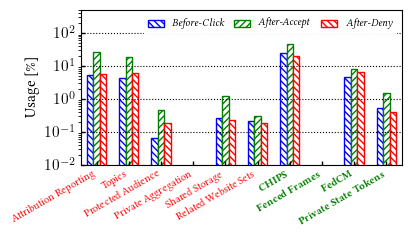

In [43]:
# First visit: consider both actions
df_count_calls_per_api_first_visit_last_week = (
    df_calls_last_week[df_calls_last_week["visit"] == "first"]
        .drop_duplicates(["website", "api"])
        .groupby("api").size()
        .rename(index=PRIVACY_SANDBOX_APIS_MAP)
)

# Second visit: count separately by action
df_count_calls_per_api_second_visit_last_week = (
    df_calls_last_week[df_calls_last_week["visit"] == "second"]
        .drop_duplicates(["website", "api", "action"])
        .groupby(["api", "action"]).size()
        .rename(index=PRIVACY_SANDBOX_APIS_MAP)
)

# Get totals for each visit and action
total_first_visit_websites_last_week = visits_counts_frames[("first", "any")].loc[last_week]
total_second_visit_accept_websites_last_week = visits_counts_frames[("second", "accept")].loc[last_week]
total_second_visit_deny_websites_last_week = visits_counts_frames[("second", "deny")].loc[last_week]

# Calculate percentages
df_usage_percentage_first_visit_last_week = 100 * df_count_calls_per_api_first_visit_last_week / total_first_visit_websites_last_week
df_usage_percentage_second_visit_accept_last_week = 100 * df_count_calls_per_api_second_visit_last_week.xs("accept", level="action") / total_second_visit_accept_websites_last_week
df_usage_percentage_second_visit_deny_last_week = 100 * df_count_calls_per_api_second_visit_last_week.xs("deny", level="action") / total_second_visit_deny_websites_last_week

df_plot = pd.DataFrame({
    VISITS_MAP[("first", "any")]: df_usage_percentage_first_visit_last_week,
    VISITS_MAP[("second", "accept")]: df_usage_percentage_second_visit_accept_last_week,
    VISITS_MAP[("second", "deny")]: df_usage_percentage_second_visit_deny_last_week
}).reindex(PRIVACY_SANDBOX_APIS_MAP.values()).rename(index={ PRIVACY_SANDBOX_APIS_MAP[api]: f"\\textbf{{{PRIVACY_SANDBOX_APIS_MAP[api]}}}" for api in SUPPORTED_APIS })

display(df_plot)

plot = fpl.plot(
    df_plot,
    path=None,
    mode='bars_multi',
    xticks_fontsize="x-small", xticks_rotate = 30,
    ylabel='Usage [\\%]', yscale="log", ylim=(0,500),
    grid_axis="y",
    legend = True, legend_loc='upper right', legend_ncol=3, legend_fontsize="x-small",
    **PLOT_ARGS
)
set_bar_colors(plot, colors=["blue", "green", "red"], legend=True)

# Set x-tick label colors based on support status
ax = plot.gca()
for tick_label, api in zip(ax.get_xticklabels(), PRIVACY_SANDBOX_APIS):
    handles, labels = ax.get_legend_handles_labels()
    color = "green" if api in SUPPORTED_APIS else "red"
    tick_label.set_color(color)

save_plot(plot, "01-api-usage-visits")
plot.show()

### Usage comparison between first and last week

,First week,Last week
api,,
Attribution Reporting,28.719447,27.017763
Topics,23.591923,19.009037
Protected Audience,6.190223,0.467435
Private Aggregation,NaN,NaN
Shared Storage,20.589798,1.215332
Related Website Sets,0.132837,0.311624
\textbf{CHIPS},47.555792,46.681209
\textbf{Fenced Frames},NaN,NaN
\textbf{FedCM},6.243358,8.195700


<Figure size 640x480 with 0 Axes>

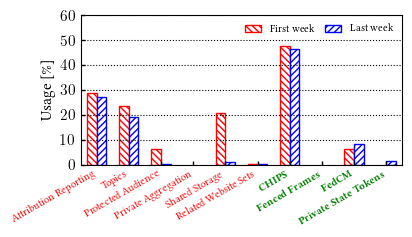

In [44]:
mk_second_accept = (df_calls_first_week["visit"] == "second") & (df_calls_first_week["action"] == "accept")
df_count_calls_per_api_second_visit_first_week = (
    df_calls_first_week[mk_second_accept]
        .pivot_table(index="api", values="website", aggfunc='nunique', fill_value=0)
        .rename(index=PRIVACY_SANDBOX_APIS_MAP, columns={"website": "count"})
)

mk_second_accept = (df_calls_last_week["visit"] == "second") & (df_calls_last_week["action"] == "accept")
df_count_calls_per_api_second_visit_last_week = (
    df_calls_last_week[mk_second_accept]
        .pivot_table(index="api", values="website", aggfunc="nunique", fill_value=0)
        .rename(index=PRIVACY_SANDBOX_APIS_MAP, columns={"website": "count"})
)

total_second_visit_accept_websites_first_week = visits_counts_frames[("second", "accept")].loc[first_week]
total_second_visit_accept_websites_last_week = visits_counts_frames[("second", "accept")].loc[last_week]

df_usage_percentage_second_visit_first_week = 100 * df_count_calls_per_api_second_visit_first_week / total_second_visit_accept_websites_first_week
df_usage_percentage_second_visit_last_week = 100 * df_count_calls_per_api_second_visit_last_week / total_second_visit_accept_websites_last_week

df_plot = pd.DataFrame({
    'First week': df_usage_percentage_second_visit_first_week.squeeze(),
    'Last week': df_usage_percentage_second_visit_last_week.squeeze()
}).reindex(PRIVACY_SANDBOX_APIS_MAP.values()).rename(index={ PRIVACY_SANDBOX_APIS_MAP[api]: f"\\textbf{{{PRIVACY_SANDBOX_APIS_MAP[api]}}}" for api in SUPPORTED_APIS })

display(df_plot)

plot = fpl.plot(
    df_plot,
    path=None,
    mode='bars_multi',
    xticks_fontsize="x-small", xticks_rotate = 30,
    ylabel='Usage [\\%]', yticks=(range(0,61,10), None),
    grid_axis="y",
    legend = True, legend_loc='upper right', legend_ncol=2, legend_fontsize="x-small", legend_alpha=0,
    **PLOT_ARGS
)
set_bar_colors(plot, colors=["red", "blue"], legend=True)

# Set x-tick label colors based on support status
ax = plot.gca()
for tick_label, api in zip(ax.get_xticklabels(), PRIVACY_SANDBOX_APIS):
    handles, labels = ax.get_legend_handles_labels()
    color = "green" if api in SUPPORTED_APIS else "red"
    tick_label.set_color(color)

save_plot(plot, "02-api-usage-first-v-last")
plot.show()

### Flow of callers

In [45]:
TOP_N = 15
CALLER_TYPE = "script"

# Count calls per caller in After Accept (last week)
mk_second_accept = (df_calls_last_week["visit"] == "second") & (df_calls_last_week["action"] == "accept")
df_count_last_week_calls_per_caller = (
    df_calls_last_week[mk_second_accept]
        .pivot_table(index=f"caller_{CALLER_TYPE}_domain", values="website", aggfunc="nunique")
        .rename(columns={'website': 'count'})
)

# Get top callers for last week
df_count_last_week_calls_per_caller.drop("UNKNOWN_SOURCE", inplace=True)
df_top_last_week_callers = df_count_last_week_calls_per_caller.sort_values('count', ascending=False).head(TOP_N)

# Filter calls from top callers (last week)
mk_top_caller = df_calls_last_week[f"caller_{CALLER_TYPE}_domain"].isin(df_top_last_week_callers.index)
df_top_calls_last_week = df_calls_last_week.loc[(mk_second_accept & mk_top_caller), [f"caller_{CALLER_TYPE}_domain", "website", "api"]]
df_top_calls_last_week["api"] = df_top_calls_last_week["api"].apply(lambda api: PRIVACY_SANDBOX_APIS_MAP[api])

# Filter calls from top callers (first week)
mk_second_accept = (df_calls_first_week["visit"] == "second") & (df_calls_first_week["action"] == "accept")
mk_top_caller = df_calls_first_week[f"caller_{CALLER_TYPE}_domain"].isin(df_top_last_week_callers.index)
df_top_calls_first_week = df_calls_first_week.loc[(mk_second_accept & mk_top_caller), [f"caller_{CALLER_TYPE}_domain", "website", "api"]]
df_top_calls_first_week["api"] = df_top_calls_first_week["api"].apply(lambda api: PRIVACY_SANDBOX_APIS_MAP[api])

# Create nodes and links for Sankey diagram
# Left: first week caller_{CALLER_TYPE}_domains
first_week_domains = df_top_calls_first_week[f'caller_{CALLER_TYPE}_domain'].unique()
# Center: APIs
apis = list(set(df_top_calls_first_week['api'].unique()) | set(df_top_calls_last_week['api'].unique()))
# Right: last week caller_{CALLER_TYPE}_domains
last_week_domains = df_top_calls_last_week[F'caller_{CALLER_TYPE}_domain'].unique()

# Create color palette for APIs
colors = [
    'rgba(174, 198, 231, 0.8)',  # pastel blue
    #'rgba(255, 179, 153, 0.8)',  # pastel peach
    'rgba(152, 223, 138, 0.8)',  # pastel green
    'rgba(255, 153, 153, 0.8)',  # pastel coral
    'rgba(197, 176, 255, 0.8)',  # pastel lavender
    'rgba(205, 193, 180, 0.8)',  # pastel beige
    'rgba(255, 204, 229, 0.8)',  # pastel pink
    'rgba(200, 200, 200, 0.8)',  # light gray
    'rgba(245, 222, 179, 0.8)',  # pastel wheat
    'rgba(162, 230, 217, 0.8)'   # pastel teal
]

# Create API to color mapping
api_colors = {api: colors[i % len(colors)] for i, api in enumerate(apis)}

# Create node labels and assign indices
nodes = (
    [f"FW_{domain}" for domain in first_week_domains] +
    [f"API_{api}" for api in apis] +
    [f"LW_{domain}" for domain in last_week_domains]
)

# Create mappings for indices
first_week_offset = 0
api_offset = len(first_week_domains)
last_week_offset = len(first_week_domains) + len(apis)

# Create links with API tracking
links = []

# Links from first week domains to APIs
for _, row in df_top_calls_first_week.iterrows():
    source = first_week_offset + list(first_week_domains).index(row[F'caller_{CALLER_TYPE}_domain'])
    target = api_offset + apis.index(row['api'])
    links.append({'source': source, 'target': target, 'value': 1, 'api': row['api']})

# Links from APIs to last week domains
for _, row in df_top_calls_last_week.iterrows():
    source = api_offset + apis.index(row['api'])
    target = last_week_offset + list(last_week_domains).index(row[F'caller_{CALLER_TYPE}_domain'])
    links.append({'source': source, 'target': target, 'value': 1, 'api': row['api']})

# Aggregate link values while preserving API information
link_counts = defaultdict(lambda: {'value': 0, 'api': None})
for link in links:
    key = (link['source'], link['target'])
    link_counts[key]['value'] += link['value']
    link_counts[key]['api'] = link['api']

# Convert back to list with colors
final_links = []
link_colors = []
for (source, target), data in link_counts.items():
    final_links.append({'source': source, 'target': target, 'value': data['value']})
    link_colors.append(api_colors[data['api']])

# Create explicit node positions to force "API_Shared Storage" to center
node_colors = []
# Remove prefixes from node labels for display
display_nodes = []
for i, node in enumerate(nodes):    
    # Set node colors - API nodes get their assigned color, others get default
    if node.startswith("API_"):
        api_name = node[4:]  # Remove "API_" prefix
        display_nodes.append(api_name)  # Store display name without prefix
        if api_name in api_colors:
            node_colors.append(api_colors[api_name])
        else:
            node_colors.append('rgba(128, 128, 128, 0.8)')  # Default gray
    elif node.startswith("FW_"):
        display_nodes.append(node[3:])  # Remove "FW_" prefix
        node_colors.append('rgba(128, 128, 128, 0.8)')  # Default gray for domain nodes
    elif node.startswith("LW_"):
        display_nodes.append(node[3:])  # Remove "LW_" prefix
        node_colors.append('rgba(128, 128, 128, 0.8)')  # Default gray for domain nodes
    else:
        display_nodes.append(node)  # Keep original if no recognized prefix
        node_colors.append('rgba(128, 128, 128, 0.8)')  # Default gray

# node_labels_blank = [''] * len(nodes)

# Create Sankey diagram
fig = go.Figure(data=[go.Sankey(
    arrangement="perpendicular",
    node=dict(
        pad=15,
        thickness=20,
        line=dict(color="black", width=0.5),
        label=display_nodes,
        color=node_colors,
        hoverlabel=dict(font_size=12, font_color="white"),
        align="left"
    ),
    link=dict(
        source=[link['source'] for link in final_links],
        target=[link['target'] for link in final_links],
        value=[link['value'] for link in final_links],
        color=link_colors
    )
)])

header_annotations = [
    dict(
        x=0.01,
        y=1.05,
        text="First week",
        showarrow=False,
        xref="paper",
        yref="paper",
        font=dict(size=14, color="black"),
        xanchor="left"
    ),
    dict(
        x=0.5,
        y=1.05,
        text="API",
        showarrow=False,
        xref="paper",
        yref="paper",
        font=dict(size=14, color="black"),
        xanchor="center"
    ),
    dict(
        x=0.99,
        y=1.05,
        text="Last Week",
        showarrow=False,
        xref="paper",
        yref="paper",
        font=dict(size=14, color="black"),
        xanchor="right"
    )
]

fig.update_layout(
    # title_text="Privacy Sandbox API Usage: First Week → APIs → Last Week",
    font_size=10,
    width=800,  # 8 inches * 100 pixels per inch
    height=1000,  # 10 inches * 100 pixels per inch
    margin=dict(l=0, r=0, t=50, b=0),
    annotations=header_annotations
)

save_sankey(fig, "03-tp-api-flow")
fig.show()

## Deprecated APIs

### Usage timeline

<Figure size 640x480 with 0 Axes>

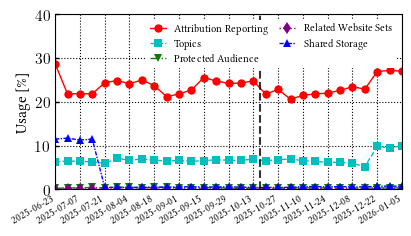

<Figure size 640x480 with 0 Axes>

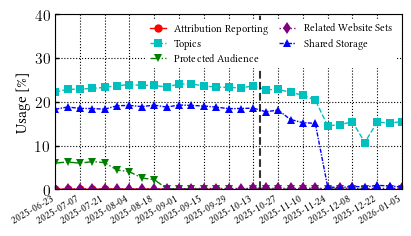

In [46]:
for party, df in [("first", df_api_fp_calls_reduced), ("third", df_api_tp_calls_reduced)]:
    mk_deprecated_second_accept = (df["visit"] == "second") & (df["action"] == "accept") & (df["api"].isin(DEPRECATED_APIS))
    df_count_calls_per_api_date = (
        df[mk_deprecated_second_accept]
            .pivot_table(index=["date", "api"], values="website", aggfunc='nunique', fill_value=0)
            .rename(columns={"website": "count"})
            .reset_index()
    )

    df_count_calls_per_api_date = df_count_calls_per_api_date.join(visits_counts_frames[('second', 'accept')], on="date", how="left").rename(columns={"website": "total_websites"})
    df_count_calls_per_api_date["usage_percentage"] = 100 * df_count_calls_per_api_date["count"] / df_count_calls_per_api_date["total_websites"]

    plot_data = [
        (PRIVACY_SANDBOX_APIS_MAP[api], (df_count_calls_per_api_date[df_count_calls_per_api_date["api"] == api]["date"], df_count_calls_per_api_date[df_count_calls_per_api_date["api"] == api]["usage_percentage"]))
        for api in DEPRECATED_APIS
    ]
    plot = fpl.plot(
        plot_data,
        path=None,
        mode='line_multi',
        xticks_fontsize="x-small", xticks=(date_ticks, date_ticks_str), xticks_rotate = 30,
        ylabel='Usage [\\%]', ylim=(0,40),# yticks=(range(0,41,10), None),
        grid_axis="both",
        legend = True, legend_loc='upper right', legend_ncol=2, legend_fontsize="x-small",
        cycler=(cycler('color', ['r', 'c', 'g', 'purple', 'b']) +
                cycler('linestyle', ['-', '--', '-.', ':', (0, (3, 1, 1, 1)) ]) +
                cycler('marker', ['o', 's', 'v', 'd', '^' ])),
        **PLOT_ARGS
    )

    # Add vertical line at deprecation date
    deprecation_timestamp = pd.to_datetime(DEPRECATION_DATE, format="%Y%m%d")
    plot.gca().axvline(x=deprecation_timestamp, color='black', linestyle='--', linewidth=1.5, alpha=0.8)

    save_plot(plot, f"04a-deprecated-timeline-{party}-party-usage")
    plot.show()

### Caller timeline

<Figure size 640x480 with 0 Axes>

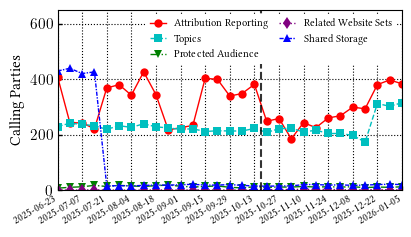

<Figure size 640x480 with 0 Axes>

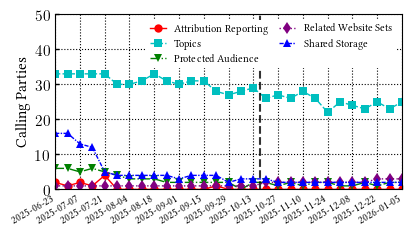

In [47]:
ylim_party = {
    "first": (0, 650),
    "third": (0, 50)
}

for party, df in [("first", df_api_fp_calls_reduced), ("third", df_api_tp_calls_reduced)]:
    mk_deprecated_second_accept = (df["visit"] == "second") & (df["action"] == "accept") & (df["api"].isin(DEPRECATED_APIS))
    df_count_callers_per_api_date = (
        df[mk_deprecated_second_accept]
            .pivot_table(index="date", columns="api",  values=f"caller_{CALLER_TYPE}_domain", aggfunc='nunique', fill_value=0)
            .rename(columns={f"caller_{CALLER_TYPE}_domain": "count"})
    )

    plot_data = [
        (PRIVACY_SANDBOX_APIS_MAP[api], (df_count_callers_per_api_date.index, df_count_callers_per_api_date[api]))
        for api in DEPRECATED_APIS
    ]
    plot = fpl.plot(
        plot_data,
        path=None,
        mode='line_multi',
        xticks_fontsize="x-small", xticks=(date_ticks, date_ticks_str), xticks_rotate = 30,
        ylabel='Calling Parties', ylim=ylim_party[party],
        grid_axis="both",
        legend = True, legend_loc='upper right', legend_ncol=2, legend_fontsize="x-small",
        cycler=(cycler('color', ['r', 'c', 'g', 'purple', 'b']) +
                cycler('linestyle', ['-', '--', '-.', ':', (0, (3, 1, 1, 1)) ]) +
                cycler('marker', ['o', 's', 'v', 'd', '^' ])),
        **PLOT_ARGS
    )

    # Add vertical line at deprecation date
    deprecation_timestamp = pd.to_datetime(DEPRECATION_DATE, format="%Y%m%d")
    plot.gca().axvline(x=deprecation_timestamp, color='black', linestyle='--', linewidth=1.5, alpha=0.8)

    save_plot(plot, f"04b-deprecated-timeline-{party}-callers")
    plot.show()

## Supported APIs

### Usage timeline

<Figure size 640x480 with 0 Axes>

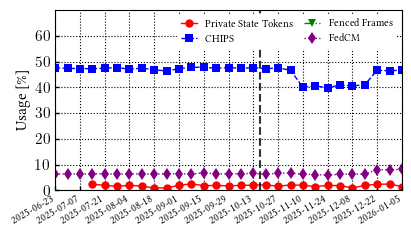

In [48]:
mk_supported_second_accept = (df_api_calls_reduced["visit"] == "second") & (df_api_calls_reduced["action"] == "accept") & (df_api_calls_reduced["api"].isin(SUPPORTED_APIS))
df_count_calls_per_api_date = (
    df_api_calls_reduced[mk_supported_second_accept]
        .pivot_table(index=["date", "api"], values="website", aggfunc='nunique', fill_value=0)
        .rename(columns={"website": "count"})
        .reset_index()
)

df_count_calls_per_api_date = df_count_calls_per_api_date.join(visits_counts_frames[('second', 'accept')], on="date", how="left").rename(columns={"website": "total_websites"})
df_count_calls_per_api_date["usage_percentage"] = 100 * df_count_calls_per_api_date["count"] / df_count_calls_per_api_date["total_websites"]

plot_data = [
    (PRIVACY_SANDBOX_APIS_MAP[api], (df_count_calls_per_api_date[df_count_calls_per_api_date["api"] == api]["date"], df_count_calls_per_api_date[df_count_calls_per_api_date["api"] == api]["usage_percentage"]))
    for api in SUPPORTED_APIS
]
plot = fpl.plot(
    plot_data,
    path=None,
    mode='line_multi',
    xticks_fontsize="x-small", xticks=(date_ticks, date_ticks_str), xticks_rotate = 30,
    ylabel='Usage [\\%]', ylim=(0,70), yticks=(range(0,70,10), None),
    grid_axis="both",
    legend = True, legend_loc='upper right', legend_ncol=2, legend_fontsize="x-small",
    cycler=fpl.CYCLER_LINESPOINTS,
    **PLOT_ARGS
)

# Add vertical line at deprecation date
deprecation_timestamp = pd.to_datetime(DEPRECATION_DATE, format="%Y%m%d")
plot.gca().axvline(x=deprecation_timestamp, color='k', linestyle='--', linewidth=1.5, alpha=0.8)

save_plot(plot, f"05a-supported-timeline-usage")
plot.show()

### Caller timeline

/opt/conda/lib/python3.13/site-packages/fastplot/__init__.py:258: UserWarning:

Attempt to set non-positive ylim on a log-scaled axis will be ignored.



<Figure size 640x480 with 0 Axes>

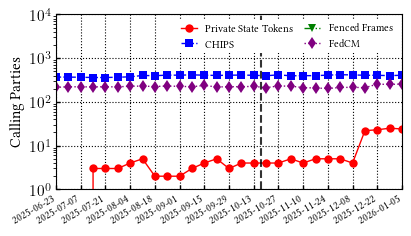

In [49]:
mk_supported_second_accept = (df_api_calls_reduced["visit"] == "second") & (df_api_calls_reduced["action"] == "accept") & (df_api_calls_reduced["api"].isin(SUPPORTED_APIS))
df_count_callers_per_api_date = (
    df_api_calls_reduced[mk_supported_second_accept]
        .pivot_table(index="date", columns="api", values=f"caller_{CALLER_TYPE}_domain", aggfunc='nunique', fill_value=0)
        .rename(columns={f"caller_{CALLER_TYPE}_domain": "count"})
        .reindex(SUPPORTED_APIS, axis="columns", fill_value=0)
)

plot_data = [
    (PRIVACY_SANDBOX_APIS_MAP[api], (df_count_callers_per_api_date.index, df_count_callers_per_api_date[api]))
    for api in SUPPORTED_APIS
]
plot = fpl.plot(
    plot_data,
    path=None,
    mode='line_multi',
    xticks_fontsize="x-small", xticks=(date_ticks, date_ticks_str), xticks_rotate = 30,
    ylabel='Calling Parties', ylim=(0,10000), yscale = "log",
    grid_axis="both",
    legend = True, legend_loc='upper right', legend_ncol=2, legend_fontsize="x-small",
    cycler=fpl.CYCLER_LINESPOINTS,
    **PLOT_ARGS
)

# Add vertical line at deprecation date
deprecation_timestamp = pd.to_datetime(DEPRECATION_DATE, format="%Y%m%d")
plot.gca().axvline(x=deprecation_timestamp, color='black', linestyle='--', linewidth=1.5, alpha=0.8)

save_plot(plot, f"05b-supported-timeline-callers")
plot.show()

## Chips: partitioned cookie usage

### Create cookies dataframe

In [32]:
COLS = [ "website", "cookie_domain", "visit", "action", "is_partitioned" ]

cookies_visit_frames = []

for action in ACTIONS:
    for visit in VISITS:
        print("Processing", visit, action)
        df_cookies_visit = df_crawling[["date", "website", f"{visit}_cookies_{action}"]].explode(f"{visit}_cookies_{action}").dropna().apply(
            lambda row: pd.Series(
                {
                    "date": row["date"],
                    "website": row["website"],
                    "cookie_domain": getGood2LD(row[f"{visit}_cookies_{action}"]["domain"]),
                    "visit": visit,
                    "action": action,
                    "is_partitioned": 'partitionKey' in row[f"{visit}_cookies_{action}"] and row[f"{visit}_cookies_{action}"]['partitionKey'] is not None,
                    "is_session": row[f"{visit}_cookies_{action}"].get("session", False)
                }
            ),
            axis="columns"
        )
        cookies_visit_frames.append(df_cookies_visit)

df_cookies = pd.concat(cookies_visit_frames)

df_cookies

Processing first accept
Processing second accept
Processing first deny
Processing second deny


,date,website,cookie_domain,visit,action,is_partitioned,is_session
0,2025-06-23,http://google.com/,google.com,first,accept,False,False
0,2025-06-23,http://google.com/,google.com,first,accept,False,False
0,2025-06-23,http://google.com/,google.com,first,accept,False,False
1,2025-06-23,http://mail.ru/,mail.ru,first,accept,False,True
1,2025-06-23,http://mail.ru/,mail.ru,first,accept,False,False
...,...,...,...,...,...,...,...
8251,2026-01-05,https://www.lesanciennes.com/,cookiepro.com,second,deny,False,False
8251,2026-01-05,https://www.lesanciennes.com/,lesanciennes.com,second,deny,False,False
8251,2026-01-05,https://www.lesanciennes.com/,lesanciennes.com,second,deny,False,False
8251,2026-01-05,https://www.lesanciennes.com/,lesanciennes.com,second,deny,False,False


In [34]:
df_cookies.to_pickle(f"{PLOTS_DIR}/pickle/df_cookies.pkl")
# df_cookies = pd.read_pickle(f"{PLOTS_DIR}/pickle/df_cookies.pkl")

In [35]:
mk_tp_cookies = ~df_cookies["website"].str.startswith("data-placeholder") & df_cookies[["website", "cookie_domain"]].apply(lambda row: is_third_party_domain(row["website"], row["cookie_domain"]), axis=1)
df_tp_cookies = df_cookies[mk_tp_cookies]
df_fp_cookies = df_cookies[~mk_tp_cookies]

### Partitioned cookie trend (November 2025)

<Figure size 640x480 with 0 Axes>

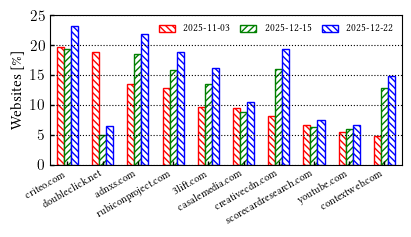

In [50]:
weeks = [ "2025-11-03", "2025-12-15", "2025-12-22" ]
weeks_dt = pd.to_datetime(weeks, format="%Y-%m-%d")

 # TODO: 3 BARRE -- PRE, DURANTE, POST

mk_partitioned_weekly = (
    (df_tp_cookies["visit"] == "second")
    & (df_tp_cookies["action"] == "accept")
    & (df_tp_cookies["date"].isin(weeks_dt))
    & (df_tp_cookies["is_partitioned"])
)
df_unpartitioned_cookies_weekly = df_tp_cookies[mk_partitioned_weekly]
df_count_partitioned_cookies_per_tp_weekly = (
    df_unpartitioned_cookies_weekly
        .pivot_table(index=["date", "cookie_domain"], values="website", aggfunc='nunique', fill_value=0)
        .rename(columns={"website": "count"})
        .reset_index()
)

df_total_websites_weekly = visits_counts_frames[("second", "accept")].loc[weeks_dt]

df_unpartitioned_cookies_weekly = df_count_partitioned_cookies_per_tp_weekly.join(
    df_total_websites_weekly, on="date", how="left"
).rename(columns={"website": "total_websites"})
df_unpartitioned_cookies_weekly["percentage"] = 100 * df_unpartitioned_cookies_weekly["count"] / df_unpartitioned_cookies_weekly["total_websites"]

df_top_callers_by_cookie_perc = df_unpartitioned_cookies_weekly.pivot_table(index="cookie_domain", values="percentage", columns="date", fill_value=0).sort_values(weeks_dt[0], ascending=False).head(10)

df_plot = df_top_callers_by_cookie_perc.rename(columns={dt: dt.strftime("%Y-%m-%d") for dt in weeks_dt})
plot = fpl.plot(
    df_plot,
    path=None,
    mode='bars_multi',
    xticks_fontsize="x-small", xticks_rotate = 30,
    ylabel='Websites [\\%]', yticks=(range(0,26,5), None),
    grid_axis="y",
    legend = True, legend_loc='upper right', legend_ncol=3, legend_fontsize="x-small",
    **PLOT_ARGS
)
set_bar_colors(plot, colors=["red", "green", "blue"], legend=True)
save_plot(plot, "08-chips-usage-trend")
plot.show()

## CHIPS vs Other APIS

<Figure size 640x480 with 0 Axes>

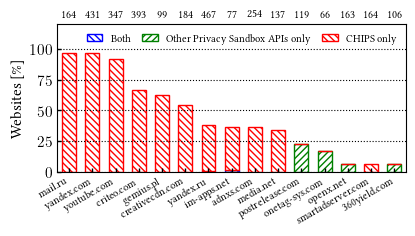

<Figure size 640x480 with 0 Axes>

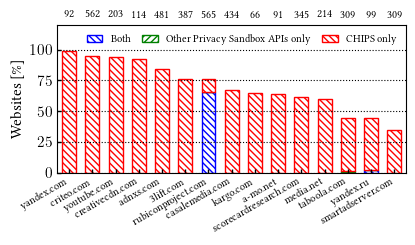

<Figure size 640x480 with 0 Axes>

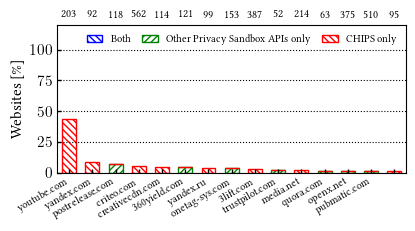

In [51]:
def get_api_set_type(api_set):
    if "chips" in api_set:
        if len(api_set) == 1:
            return "chips"
        else:
            return "both"
    return "ps"

df_last_week = df_crawling[df_crawling["date"].eq(last_week)]

for visit, action in ("first", "any"), ("second", "accept"), ("second", "deny"):

    # Get third-party presence data for last week
    if action == "any":
        df_tp_presence = pd.concat([
            df_last_week[["website", f"{visit}_contacted_domains_accept"]].explode(f"{visit}_contacted_domains_accept").dropna(subset=[f"{visit}_contacted_domains_accept"]).rename(columns={f"{visit}_contacted_domains_accept": "contacted_domain"}),
            df_last_week[["website", f"{visit}_contacted_domains_deny"]].explode(f"{visit}_contacted_domains_deny").dropna(subset=[f"{visit}_contacted_domains_deny"]).rename(columns={f"{visit}_contacted_domains_deny": "contacted_domain"}),
        ]).drop_duplicates()
    #elif visit == "second":
    #    df_tp_presence = pd.concat([
    #        df_last_week[["website", f"first_contacted_domains_{action}"]].explode(f"first_contacted_domains_{action}").dropna(subset=[f"first_contacted_domains_{action}"]).rename(columns={f"first_contacted_domains_{action}": "contacted_domain"}),
    #        df_last_week[["website", f"second_contacted_domains_{action}"]].explode(f"second_contacted_domains_{action}").dropna(subset=[f"second_contacted_domains_{action}"]).rename(columns={f"second_contacted_domains_{action}": "contacted_domain"}),
    #    ]).drop_duplicates()
    else:
        df_tp_presence = df_last_week[["website", f"{visit}_contacted_domains_accept"]].explode(f"{visit}_contacted_domains_accept").dropna(subset=[f"{visit}_contacted_domains_accept"]).rename(columns={f"{visit}_contacted_domains_accept": "contacted_domain"})

    # We consider only the 2LDs
    df_tp_presence["contacted_domain"] = df_tp_presence["contacted_domain"].apply(getGood2LD)
    df_tp_presence = df_tp_presence.drop_duplicates()

    # Count third-party domain presence
    df_count_contacted_domains = (
        df_tp_presence
            .pivot_table(index="contacted_domain", values="website", aggfunc='nunique', fill_value=0)
            .rename(columns={"website": "total_websites"})
    )

    # Filter domains present in >= 10 websites
    df_count_contacted_domains = df_count_contacted_domains[df_count_contacted_domains["total_websites"] >= 50]

    mk_visit_action_last_week = (df_api_calls_reduced["date"] == last_week) & (df_api_calls_reduced["visit"] == visit)
    if action != "any":
        mk_visit_action_last_week &= (df_api_calls_reduced["action"] == action)
    mk_known_caller = df_api_calls_reduced[f"caller_{CALLER_TYPE}_domain"] != "UNKNOWN_SOURCE"
    df_api_calls_group_caller_website_by_type = (
        df_api_calls_reduced[mk_visit_action_last_week & mk_known_caller]
            .groupby(["website", f"caller_{CALLER_TYPE}_domain"])["api"]
            .agg(set).reset_index()
    )

    # Consider only callers that are present in the contacted third-party domains
    df_api_calls_group_caller_website_by_type = df_api_calls_group_caller_website_by_type.merge(
        df_tp_presence,
        left_on=["website", f"caller_{CALLER_TYPE}_domain"],
        right_on=["website", "contacted_domain"],
        how="inner"
    )

    # API set type: tells us whether only CHIPS, only the rest of the Privacy Sandbox APIs, or both were called by the caller in the website
    df_api_calls_group_caller_website_by_type["api_set_type"] = df_api_calls_group_caller_website_by_type["api"].apply(get_api_set_type)

    df_count_api_set_type_by_caller = (
        df_api_calls_group_caller_website_by_type
            .pivot_table(index=f"caller_{CALLER_TYPE}_domain", columns="api_set_type", values="website", aggfunc='nunique', fill_value=0)
    )

    # Join with API usage data
    df_api_calls_group_caller_website_by_type = (
        df_count_api_set_type_by_caller.merge(
            df_count_contacted_domains, left_on=f"caller_{CALLER_TYPE}_domain", right_on="contacted_domain", right_index=True, how="inner"
        )
    )

    for api_set_type in ["chips", "ps", "both"]:
        df_api_calls_group_caller_website_by_type[f"percentage_{api_set_type}"] = 100 * df_api_calls_group_caller_website_by_type.get(api_set_type, 0) / df_api_calls_group_caller_website_by_type["total_websites"]

    df_api_calls_group_caller_website_by_type["percentage_total"] = df_api_calls_group_caller_website_by_type[[f"percentage_{api_set_type}" for api_set_type in ["chips", "ps", "both"]]].sum(axis=1)

    df_api_calls_group_caller_website_by_type_top = df_api_calls_group_caller_website_by_type.sort_values("percentage_total", ascending=False).head(15)

    df_plot = df_api_calls_group_caller_website_by_type_top[[f"percentage_{api_set_type}" for api_set_type in ["both", "ps", "chips"]]].rename(columns={
        "percentage_chips": "CHIPS only",
        "percentage_ps": "Other Privacy Sandbox APIs only",
        "percentage_both": "Both"
    })

    plot = fpl.plot(
        df_plot,
        path=None,
        mode='bars_stacked',
        xticks_fontsize="x-small", xticks_rotate = 30,
        ylabel='Websites [\\%]', ylim=(0,120), yticks=(range(0,101,25), None),
        grid_axis="y",
        legend = True, legend_loc='upper right', legend_ncol=3, legend_fontsize="x-small", legend_alpha=0,
        **PLOT_ARGS
    )
    set_bar_colors(plot, colors=["blue", "green", "red"], legend=True)
    add_numbers_top(plot, numbers=df_api_calls_group_caller_website_by_type_top["total_websites"].astype(int).tolist())

    plot.subplots_adjust(left=0.13, bottom=0.26, right=0.95, top=0.85)

    save_plot(plot, f"09b-chips-vs-others-{visit}-{action}")
    plot.show()